# Podsumowanie wyników bazowych i analiza warunków oświetleniowych

Celem etapu jest uporządkowanie wyników uzyskanych podczas wcześniejszych eksperymentów oraz przygotowanie podstaw do badania wpływu warunków oświetleniowych na skuteczność klasyfikacji znaków drogowych.

Na podstawie wcześniejszych eksperymentów przyjęto `ResNet50` jako model wykorzystywany w dalszej analizie oraz `WeightedRandomSampler` jako strategię kompensacji niezbalansowania klas.

Drugi cel stanowi identyfikacja obrazów reprezentujących różne poziomy jasności oraz ocena skuteczności modelu dla skrajnych warunków jasności.

Poziomy jasności są definiowane na podstawie rozkładu średniej jasności w zbiorze treningowym. Progi wyznaczane są niezależnie od zbiorów walidacyjnego i testowego i następnie stosowane do nich bez zmian.

In [ ]:
from pathlib import Path
import sys
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics import classification_report

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.transforms import (
    build_eval_transform,
)

from src.models.resnet50 import (
    create_resnet50,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "lighting_analysis"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


for directory in [
    METRICS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "PROJECT_ROOT:",
    PROJECT_ROOT
)

print(
    "METADATA_DIR:",
    METADATA_DIR
)

PROJECT_ROOT: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska
METADATA_DIR: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\data\data\processed\metadata


## 1. Wczytanie metadanych

In [2]:
inventory_path = (
    METADATA_DIR
    / "11_full_image_inventory_with_features.csv"
)

if not inventory_path.exists():

    candidates = list(
        METADATA_DIR.glob(
            "*full_image_inventory*.csv"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "Nie znaleziono pliku "
            "z pełnym inventory obrazów."
        )

    inventory_path = candidates[0]


train_path = (
    METADATA_DIR
    / "07_train.csv"
)

validation_path = (
    METADATA_DIR
    / "08_validation.csv"
)

test_path = (
    METADATA_DIR
    / "09_test_final.csv"
)


df = pd.read_csv(
    inventory_path
)

train_df = pd.read_csv(
    train_path
)

validation_df = pd.read_csv(
    validation_path
)

test_df = pd.read_csv(
    test_path
)


print(
    "Liczba obrazów w inventory:",
    len(df)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba obrazów w inventory: 21044
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 2. Kontrola metadanych jasności

Przed rozpoczęciem analizy sprawdzana jest obecność informacji dotyczących średniej jasności obrazu.

In [3]:
required_columns = {
    "path",
    "class_code",
    "source_split",
    "mean_brightness",
}

missing_columns = (
    required_columns
    - set(df.columns)
)


if missing_columns:
    raise ValueError(
        "Brakujące kolumny w inventory: "
        f"{sorted(missing_columns)}"
    )


print(
    "Wszystkie wymagane kolumny są dostępne."
)

print(
    "Zakres średniej jasności:",
    round(
        df["mean_brightness"].min(),
        2
    ),
    "-",
    round(
        df["mean_brightness"].max(),
        2
    ),
)

Wszystkie wymagane kolumny są dostępne.
Zakres średniej jasności: 10.5 - 245.26


## 3. Podsumowanie wcześniejszych eksperymentów

Wcześniejsze eksperymenty doprowadziły do wyboru `WeightedRandomSampler` jako strategii kompensacji niezbalansowania klas oraz `ResNet50` jako podstawowej architektury wykorzystywanej w dalszych badaniach.

Wyniki te są traktowane jako punkt odniesienia dla analizy wpływu warunków oświetleniowych.

In [4]:
balance_results_path = (
    METRICS_DIR
    / "balance_strategy_validation_comparison.csv"
)

architecture_results_path = (
    METRICS_DIR
    / "architecture_frozen_validation_comparison.csv"
)


if balance_results_path.exists():

    balance_results = pd.read_csv(
        balance_results_path
    )

    print(
        "Wyniki porównania strategii balansowania:"
    )

    display(
        balance_results
    )


if architecture_results_path.exists():

    architecture_results = pd.read_csv(
        architecture_results_path
    )

    print(
        "Wyniki porównania architektur:"
    )

    display(
        architecture_results
    )

Wyniki porównania strategii balansowania:


,experiment,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,weighted_sampler,0.881369,0.857666,0.906036,0.859755,57.237115
1,baseline,0.940287,0.889067,0.830464,0.843946,65.889806
2,weighted_loss,0.716561,0.645040,0.693548,0.631092,63.650711


Wyniki porównania architektur:


,model,phase,accuracy,macro_precision,macro_recall,macro_f1,best_val_macro_f1,training_time_seconds
0,resnet50,frozen,0.872213,0.866195,0.869549,0.858960,0.858960,16647.141073
1,mobilenet_v3,frozen,0.843949,0.850071,0.859516,0.840246,0.840246,4606.707235
2,efficientnet_b0,frozen,0.847134,0.803489,0.848840,0.819300,0.819300,7143.604567


## 4. Charakterystyka rozkładu jasności

Analizowany jest rozkład średniej jasności obrazów. Wartości te stanowią podstawę do zdefiniowania grup reprezentujących skrajnie niską, typową oraz skrajnie wysoką jasność.

In [5]:
train_brightness = (
    train_df[
        "mean_brightness"
    ]
)

print(
    "Statystyki średniej jasności TRAIN:"
)

display(
    train_brightness.describe()
)

Statystyki średniej jasności TRAIN:


count    14232.000000
mean       113.557930
std         41.094958
min         11.681826
25%         83.386284
50%        112.713959
75%        142.873722
max        245.255142
Name: mean_brightness, dtype: float64

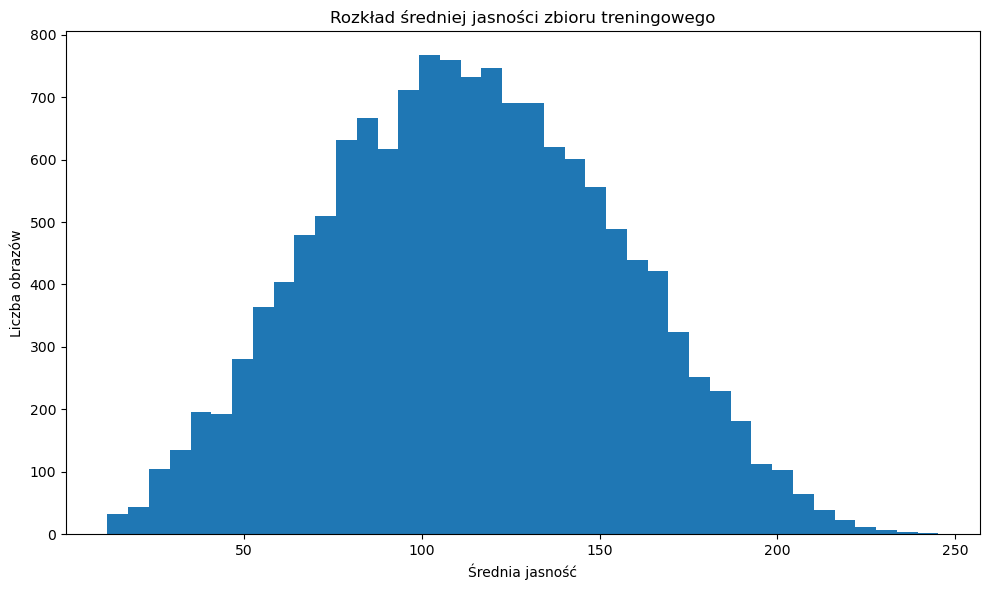

In [6]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    train_brightness.dropna(),
    bins=40,
)

ax.set_title(
    "Rozkład średniej jasności zbioru treningowego"
)

ax.set_xlabel(
    "Średnia jasność"
)

ax.set_ylabel(
    "Liczba obrazów"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "01_train_brightness_distribution.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

## 5. Definicja grup jasności

W celu wyodrębnienia obrazów reprezentujących skrajne poziomy jasności zastosowano 10. i 90. percentyl rozkładu średniej jasności zbioru treningowego.

Przyjęto trzy grupy:

- `dark` — wartości należące do dolnych 10% rozkładu,
- `normal` — wartości pomiędzy 10. i 90. percentylem,
- `bright` — wartości należące do górnych 10% rozkładu.

Takie podejście pozwala skoncentrować analizę na przypadkach o skrajnie niskiej i skrajnie wysokiej jasności, przy jednoczesnym zachowaniu największej części zbioru jako grupy odniesienia.

Progi są wyznaczane wyłącznie na podstawie zbioru treningowego.

In [7]:
brightness_p10 = float(
    train_brightness.quantile(
        0.10
    )
)

brightness_p90 = float(
    train_brightness.quantile(
        0.90
    )
)


print(
    f"P10 = {brightness_p10:.2f}"
)

print(
    f"P90 = {brightness_p90:.2f}"
)

print(
    f"Zakres normalnej jasności: "
    f"{brightness_p10:.2f} < x < "
    f"{brightness_p90:.2f}"
)

P10 = 59.54
P90 = 168.24
Zakres normalnej jasności: 59.54 < x < 168.24


In [8]:
def assign_brightness_group(
    value,
    p10,
    p90,
):

    if pd.isna(value):
        return "unknown"

    if value <= p10:
        return "dark"

    if value >= p90:
        return "bright"

    return "normal"

In [9]:
df["brightness_group"] = (
    df["mean_brightness"]
    .apply(
        lambda value:
        assign_brightness_group(
            value,
            brightness_p10,
            brightness_p90,
        )
    )
)


train_lighting = df[
    df["source_split"]
    == "train_original"
].copy()

validation_lighting = df[
    df["source_split"]
    == "validation"
].copy()

test_lighting = df[
    df["source_split"]
    == "test_original"
].copy()


print(
    "Grupy jasności zostały przypisane."
)



Grupy jasności zostały przypisane.


In [10]:
if "validation" not in df["source_split"].unique():

    validation_lighting = df[
        df["path"].isin(
            validation_df["path"]
        )
    ].copy()


print(
    "TRAIN lighting:",
    len(train_lighting)
)

print(
    "VALIDATION lighting:",
    len(validation_lighting)
)

print(
    "TEST lighting:",
    len(test_lighting)
)

TRAIN lighting: 16746
VALIDATION lighting: 2512
TEST lighting: 4298


## 6. Zapis progów jasności

Wyznaczone wartości progowe są zapisywane w celu zachowania pełnej powtarzalności eksperymentu.

In [11]:
brightness_thresholds = {
    "method": "percentiles",
    "lower_percentile": 0.10,
    "upper_percentile": 0.90,
    "dark_threshold": brightness_p10,
    "bright_threshold": brightness_p90,
    "groups": {
        "dark": (
            f"x <= {brightness_p10:.2f}"
        ),
        "normal": (
            f"{brightness_p10:.2f} < x < "
            f"{brightness_p90:.2f}"
        ),
        "bright": (
            f"x >= {brightness_p90:.2f}"
        ),
    },
    "threshold_source": "train_only",
}


(
    REPORTS_DIR
    / "brightness_thresholds.json"
).write_text(
    json.dumps(
        brightness_thresholds,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        brightness_thresholds,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "method": "percentiles",
  "lower_percentile": 0.1,
  "upper_percentile": 0.9,
  "dark_threshold": 59.53968009948732,
  "bright_threshold": 168.24337310791014,
  "groups": {
    "dark": "x <= 59.54",
    "normal": "59.54 < x < 168.24",
    "bright": "x >= 168.24"
  },
  "threshold_source": "train_only"
}


Przypisanie obrazu do grupy jasności zostało wykonane na podstawie średniej jasności całego obrazu. Ze względu na możliwość wpływu tła na wartość tego parametru przeprowadzono dodatkową kontrolę wizualną reprezentatywności utworzonych grup.

Kontrola ma na celu określenie, czy obrazy zakwalifikowane do grup `dark` i `bright` rzeczywiście reprezentują skrajne warunki jasności, czy też klasyfikacja może wynikać z lokalnych właściwości obrazu, takich jak jasne lub ciemne tło.

In [12]:
def show_lighting_examples(
    dataframe,
    group_name,
    n=12,
    seed=42,
):

    group = dataframe[
        dataframe[
            "brightness_group"
        ]
        == group_name
    ].copy()


    if len(group) == 0:

        print(
            "Brak obrazów dla grupy:",
            group_name
        )

        return


    sample = group.sample(
        min(
            n,
            len(group)
        ),
        random_state=seed,
    )


    columns = 4

    rows = math.ceil(
        len(sample)
        / columns
    )


    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            14,
            3.5 * rows
        )
    )


    axes = np.asarray(
        axes
    ).reshape(-1)


    for axis, (_, row) in zip(
        axes,
        sample.iterrows(),
    ):

        image = Image.open(
            row["path"]
        ).convert("RGB")


        axis.imshow(
            image
        )


        axis.set_title(
            f'{row["class_code"]} | '
            f'B={row["mean_brightness"]:.1f}'
        )


        axis.axis("off")


    for axis in axes[
        len(sample):
    ]:

        axis.axis("off")


    fig.suptitle(
        f"Przykładowe obrazy — {group_name}"
    )


    plt.tight_layout()

    plt.show()

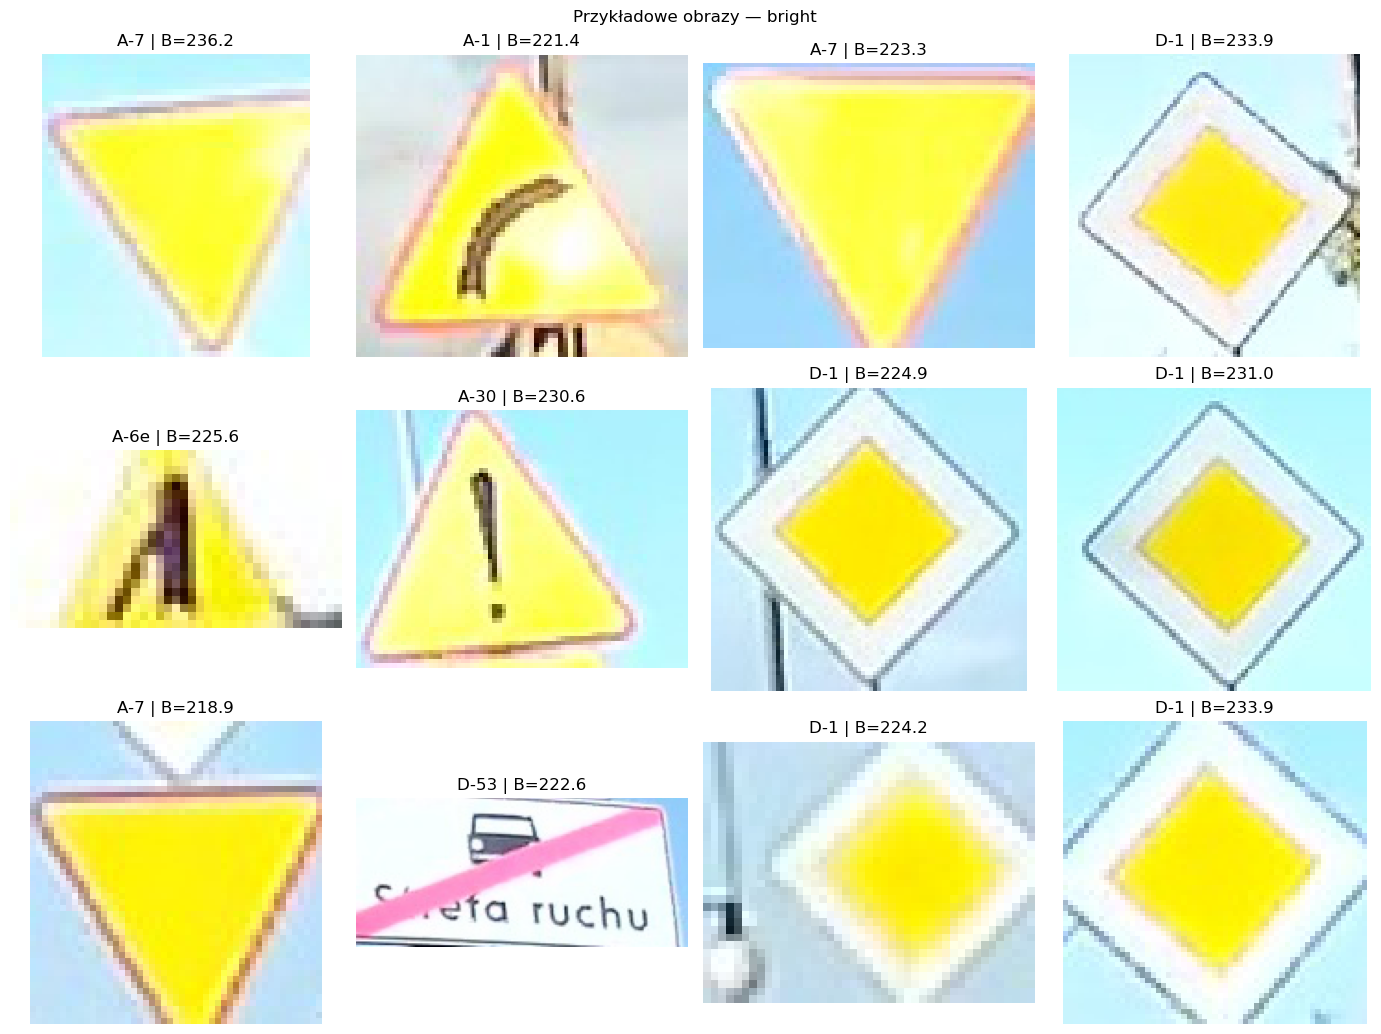

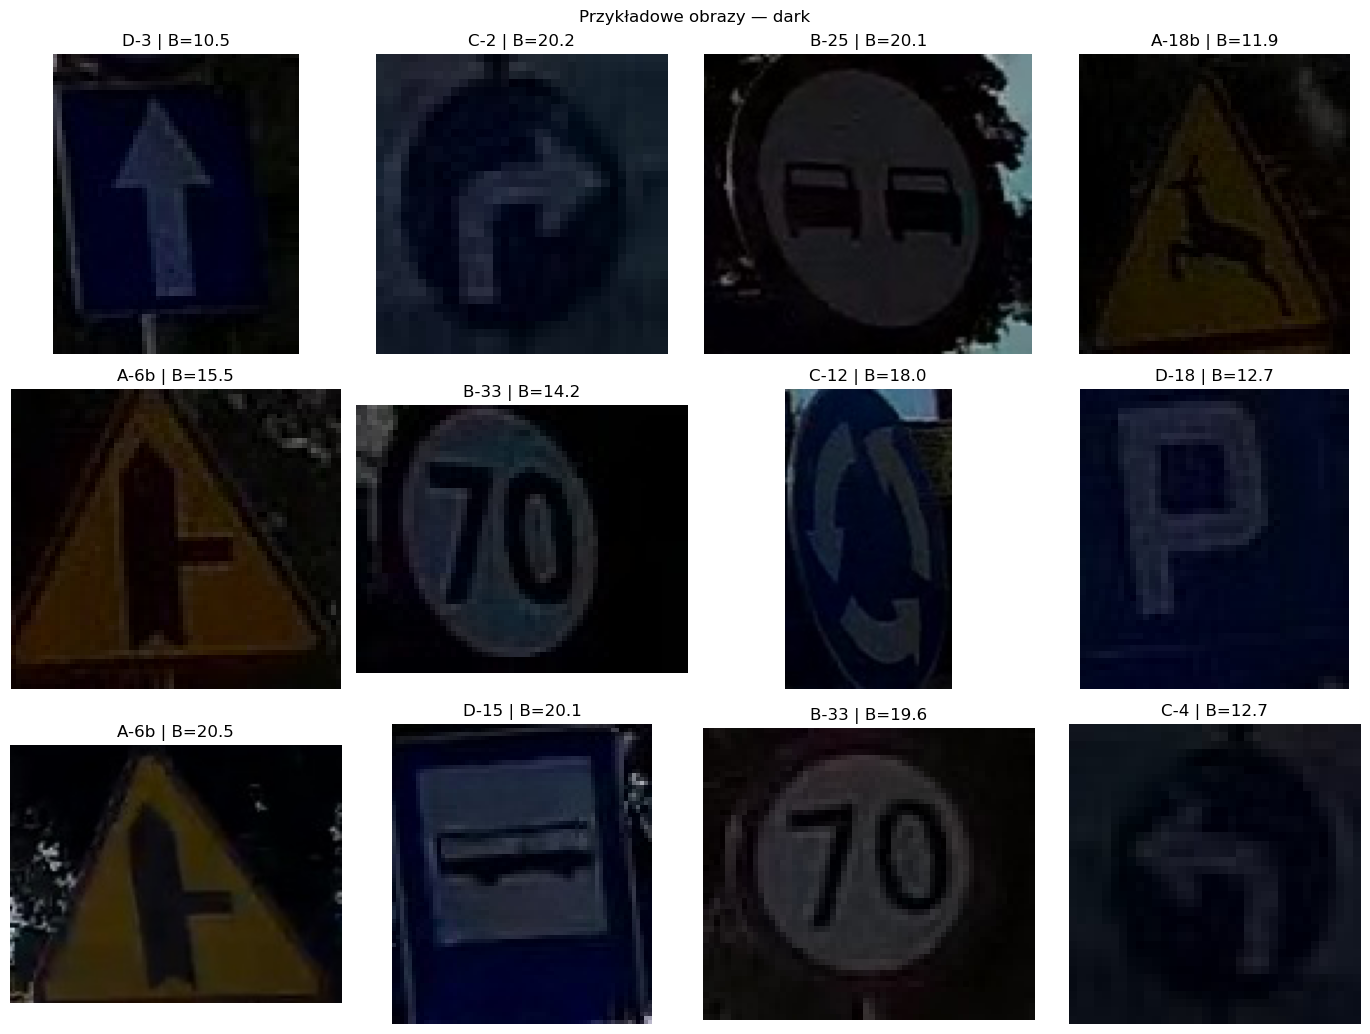

In [13]:
bright_examples = (
    test_lighting
    .sort_values(
        "mean_brightness",
        ascending=False,
    )
    .head(20)
)

dark_examples = (
    test_lighting
    .sort_values(
        "mean_brightness",
        ascending=True,
    )
    .head(20)
)

show_lighting_examples(
    bright_examples,
    "bright"
)

show_lighting_examples(
    dark_examples,
    "dark"
)

## 7. Liczność grup jasności

Analizowana jest liczność oraz procentowy udział grup `dark`, `normal` i `bright` w poszczególnych zbiorach.

In [14]:
all_split_frames = []

train_lighting = train_lighting.copy()
validation_lighting = validation_lighting.copy()
test_lighting = test_lighting.copy()


train_lighting["analysis_split"] = (
    "train"
)

validation_lighting[
    "analysis_split"
] = "validation"

test_lighting[
    "analysis_split"
] = "test"


lighting_analysis_df = pd.concat(
    [
        train_lighting,
        validation_lighting,
        test_lighting,
    ],
    ignore_index=True,
)

In [15]:
brightness_distribution = (
    lighting_analysis_df
    .groupby(
        [
            "analysis_split",
            "brightness_group",
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)


brightness_distribution[
    "percentage"
] = (
    brightness_distribution
    .groupby(
        "analysis_split"
    )["count"]
    .transform(
        lambda x:
        100 * x / x.sum()
    )
)


display(
    brightness_distribution
)


brightness_distribution.to_csv(
    REPORTS_DIR
    / "brightness_distribution_by_split.csv",
    index=False,
    encoding="utf-8-sig",
)

,analysis_split,brightness_group,count,percentage
0,test,bright,509,11.842718
1,test,dark,505,11.749651
2,test,normal,3284,76.407631
3,train,bright,1663,9.930730
4,train,dark,1667,9.954616
5,train,normal,13416,80.114654
6,validation,bright,239,9.514331
7,validation,dark,241,9.593949
8,validation,normal,2032,80.891720


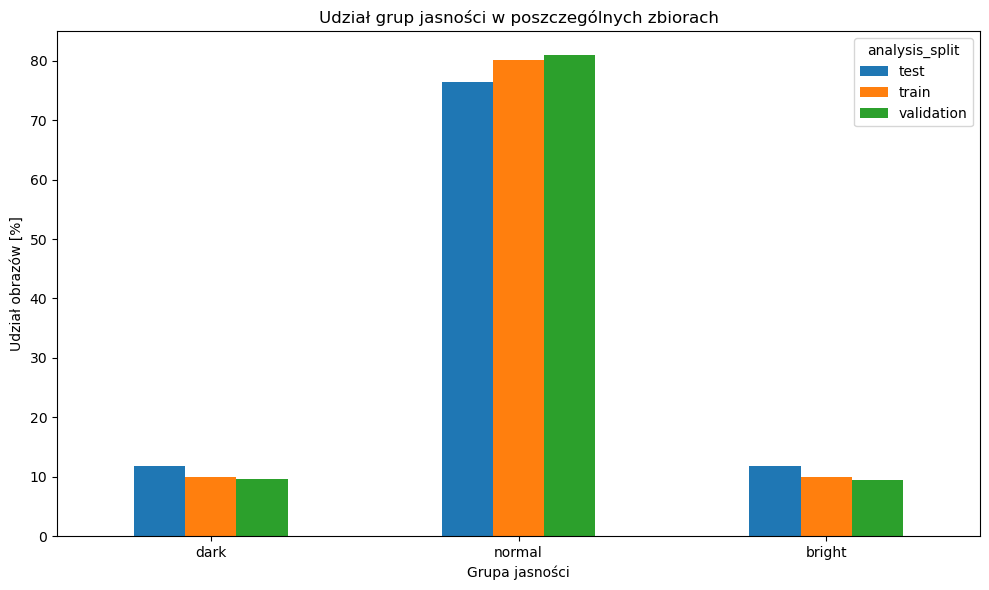

In [16]:
plot_data = (
    brightness_distribution
    .pivot(
        index="brightness_group",
        columns="analysis_split",
        values="percentage",
    )
    .fillna(0)
)


plot_data = plot_data.reindex(
    [
        "dark",
        "normal",
        "bright",
    ]
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

plot_data.plot(
    kind="bar",
    ax=ax,
)

ax.set_title(
    "Udział grup jasności w poszczególnych zbiorach"
)

ax.set_xlabel(
    "Grupa jasności"
)

ax.set_ylabel(
    "Udział obrazów [%]"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "02_brightness_groups_percentage.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

## 8. Reprezentacja klas w grupach jasności

Ze względu na niezbalansowanie klas sprawdzana jest liczba przykładów poszczególnych klas w każdej grupie jasności.

Analiza ta pozwala ocenić, czy wyniki klasyfikacji dla grup skrajnej jasności są reprezentatywne dla szerokiego zakresu klas.

In [17]:
class_brightness_counts = pd.crosstab(
    test_lighting[
        "class_code"
    ],
    test_lighting[
        "brightness_group"
    ],
)


class_brightness_counts = (
    class_brightness_counts
    .reindex(
        columns=[
            "dark",
            "normal",
            "bright",
        ],
        fill_value=0,
    )
)


display(
    class_brightness_counts
)


class_brightness_counts.to_csv(
    REPORTS_DIR
    / "class_brightness_counts_test.csv",
    encoding="utf-8-sig",
)

brightness_group,dark,normal,bright
class_code,,,
A-1,7,34,9
A-11,2,9,0
A-11a,0,9,1
A-12a,3,15,3
A-14,1,10,0
...,...,...,...
D-8,6,27,0
D-9,0,8,0
D-tablica,6,9,0


In [18]:
group_class_coverage = (
    test_lighting
    .groupby(
        "brightness_group"
    )["class_code"]
    .nunique()
    .reindex(
        [
            "dark",
            "normal",
            "bright",
        ]
    )
    .reset_index(
        name="number_of_classes"
    )
)


display(
    group_class_coverage
)


group_class_coverage.to_csv(
    REPORTS_DIR
    / "brightness_group_class_coverage_test.csv",
    index=False,
    encoding="utf-8-sig",
)

,brightness_group,number_of_classes
0,dark,73
1,normal,89
2,bright,53


## 9. Zapis metadanych dotyczących jasności

Informacje dotyczące jasności oraz przypisania obrazu do grupy są zapisywane jako dane wejściowe do kolejnych eksperymentów.

In [19]:
lighting_metadata = lighting_analysis_df[
    [
        "path",
        "filename",
        "class_code",
        "analysis_split",
        "mean_brightness",
        "median_brightness",
        "std_brightness",
        "dark_pixel_ratio",
        "bright_pixel_ratio",
        "brightness_group",
    ]
].copy()


lighting_metadata.to_csv(
    REPORTS_DIR
    / "lighting_metadata.csv",
    index=False,
    encoding="utf-8-sig",
)


print(
    "Zapisano:",
    REPORTS_DIR
    / "lighting_metadata.csv"
)

Zapisano: C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\reports\lighting_analysis\lighting_metadata.csv


## 10. Przygotowanie modelu ResNet50

W analizie wykorzystano najlepszy model ResNet50 uzyskany w poprzednim eksperymencie. Model jest wczytywany z zapisanego checkpointu i nie jest ponownie trenowany.

Celem jest wyłącznie ocena skuteczności istniejącego modelu dla grup obrazów o różnym poziomie jasności.

In [20]:
class_codes = sorted(
    df["class_code"]
    .astype(str)
    .unique()
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

Liczba klas: 92


## 11. Dataset testowy

In [21]:
test_dataset = TrafficSignDataset(
    test_path,
    class_to_idx,
    transform=build_eval_transform(
        224
    ),
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)


print(
    "Liczba obrazów testowych:",
    len(test_dataset)
)

Liczba obrazów testowych: 4298


In [22]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


checkpoint_path = (
    CHECKPOINT_DIR
    / "resnet50_finetuned_best.pt"
)


if not checkpoint_path.exists():
    raise FileNotFoundError(
        "Nie znaleziono checkpointu: "
        f"{checkpoint_path}"
    )


resnet50_model = create_resnet50(
    num_classes=len(
        class_to_idx
    ),
    pretrained=False,
)


state_dict = torch.load(
    checkpoint_path,
    map_location=DEVICE,
)


resnet50_model.load_state_dict(
    state_dict
)


resnet50_model = (
    resnet50_model.to(
        DEVICE
    )
)


resnet50_model.eval()


print(
    "Model ResNet50 został "
    "wczytany z checkpointu."
)

Model ResNet50 został wczytany z checkpointu.


## 12. Predykcja zbioru testowego

Predykcja jest wykonywana dla całego zbioru testowego jednokrotnie. Następnie wyniki są łączone z metadanymi dotyczącymi poziomu jasności.

In [23]:
test_true, test_pred, test_time = (
    predict(
        resnet50_model,
        test_loader,
        DEVICE,
    )
)


print(
    "Liczba predykcji:",
    len(test_pred)
)

print(
    "Czas inferencji:",
    round(
        test_time,
        2
    ),
    "s",
)

Liczba predykcji: 4298
Czas inferencji: 355.42 s


In [24]:
test_predictions = (
    test_dataset.data.copy()
)


test_predictions[
    "true_index"
] = (
    test_predictions[
        "class_code"
    ]
    .astype(str)
    .map(
        class_to_idx
    )
)


test_predictions[
    "pred_index"
] = test_pred


brightness_lookup = (
    test_lighting[
        [
            "path",
            "mean_brightness",
            "brightness_group",
        ]
    ]
    .drop_duplicates(
        "path"
    )
    .set_index(
        "path"
    )
)


if (
    "mean_brightness"
    not in test_predictions.columns
):

    test_predictions[
        "mean_brightness"
    ] = test_predictions[
        "path"
    ].map(
        brightness_lookup[
            "mean_brightness"
        ]
    )


test_predictions[
    "brightness_group"
] = test_predictions[
    "path"
].map(
    brightness_lookup[
        "brightness_group"
    ]
)


test_predictions[
    "correct"
] = (
    test_predictions[
        "true_index"
    ]
    ==
    test_predictions[
        "pred_index"
    ]
)


display(
    test_predictions[
        [
            "class_code",
            "mean_brightness",
            "brightness_group",
            "true_index",
            "pred_index",
            "correct",
        ]
    ].head()
)

,class_code,mean_brightness,brightness_group,true_index,pred_index,correct
0,A-1,62.330368,normal,0,0,True
1,A-1,42.037785,dark,0,9,False
2,A-1,109.184448,normal,0,0,True
3,A-1,166.445236,normal,0,0,True
4,A-1,65.179718,normal,0,35,False


## 13. Bazowa ocena ResNet50 na całym zbiorze testowym

Przed analizą poszczególnych grup jasności obliczana jest ogólna skuteczność modelu na całym zbiorze testowym.

Wynik ten stanowi punkt odniesienia dla wyników uzyskiwanych dla poszczególnych poziomów jasności.

In [25]:
overall_metrics = evaluate_predictions(
    test_true,
    test_pred,
)


overall_results = {
    "group": "all",
    "samples": len(
        test_predictions
    ),
    "accuracy": overall_metrics[
        "accuracy"
    ],
    "macro_precision": overall_metrics[
        "macro_precision"
    ],
    "macro_recall": overall_metrics[
        "macro_recall"
    ],
    "macro_f1": overall_metrics[
        "macro_f1"
    ],
}


overall_results_df = pd.DataFrame(
    [overall_results]
)


display(
    overall_results_df
)

,group,samples,accuracy,macro_precision,macro_recall,macro_f1
0,all,4298,0.900186,0.887208,0.892575,0.88298


## 14. Ocena ResNet50 według poziomu jasności

Skuteczność modelu jest analizowana oddzielnie dla grup `dark`, `normal` i `bright`.

W każdej grupie obliczane są accuracy, macro precision, macro recall oraz macro F1.

In [26]:
lighting_results = []


for group_name in [
    "dark",
    "normal",
    "bright",
]:

    group = test_predictions[
        test_predictions[
            "brightness_group"
        ]
        == group_name
    ].copy()


    y_true_group = (
        group[
            "true_index"
        ]
        .astype(int)
        .to_numpy()
    )


    y_pred_group = (
        group[
            "pred_index"
        ]
        .astype(int)
        .to_numpy()
    )


    metrics = evaluate_predictions(
        y_true_group,
        y_pred_group,
    )


    lighting_results.append(
        {
            "brightness_group":
                group_name,

            "samples":
                len(group),

            "classes_present":
                group[
                    "class_code"
                ].nunique(),

            "mean_brightness":
                group[
                    "mean_brightness"
                ].mean(),

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],
        }
    )


lighting_results_df = (
    pd.DataFrame(
        lighting_results
    )
)


display(
    lighting_results_df
)

,brightness_group,samples,classes_present,mean_brightness,accuracy,macro_precision,macro_recall,macro_f1
0,dark,505,73,44.809502,0.851485,0.794088,0.799085,0.784413
1,normal,3284,89,112.519203,0.904080,0.889345,0.897246,0.885292
2,bright,509,53,186.653936,0.923379,0.889834,0.898456,0.882323


In [27]:
lighting_results_with_overall = pd.concat(
    [
        overall_results_df.rename(
            columns={
                "group":
                    "brightness_group"
            }
        ),
        lighting_results_df,
    ],
    ignore_index=True,
    sort=False,
)


display(
    lighting_results_with_overall
)


lighting_results_with_overall.to_csv(
    METRICS_DIR
    / "resnet50_lighting_group_test.csv",
    index=False,
    encoding="utf-8-sig",
)

,brightness_group,samples,accuracy,macro_precision,macro_recall,macro_f1,classes_present,mean_brightness
0,all,4298,0.900186,0.887208,0.892575,0.882980,NaN,NaN
1,dark,505,0.851485,0.794088,0.799085,0.784413,73.0,44.809502
2,normal,3284,0.904080,0.889345,0.897246,0.885292,89.0,112.519203
3,bright,509,0.923379,0.889834,0.898456,0.882323,53.0,186.653936


## 15. Porównanie skuteczności dla poziomów jasności

Porównanie wartości macro F1 pozwala określić, czy skrajne poziomy jasności są związane ze zmianą skuteczności klasyfikacji modelu.

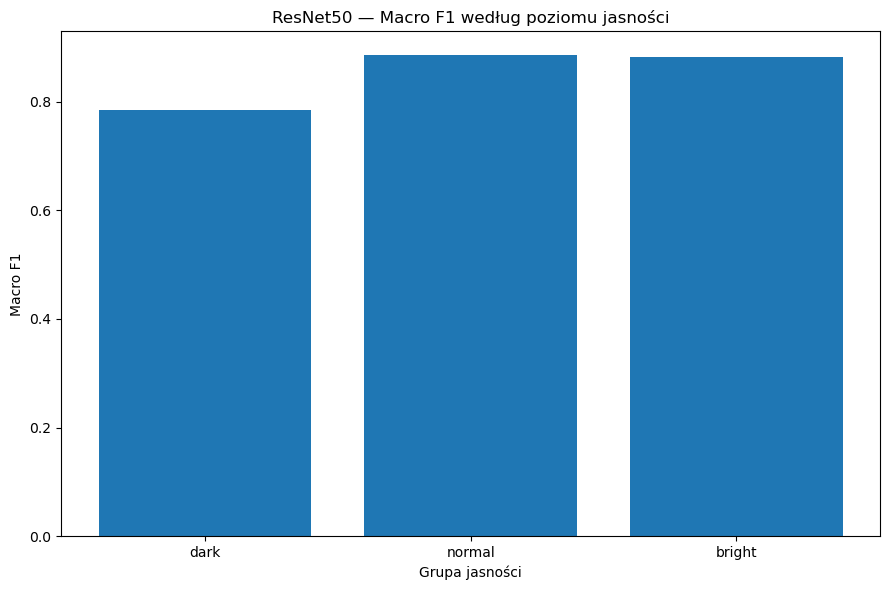

In [28]:
plot_df = lighting_results_df.copy()

plot_df = plot_df.set_index(
    "brightness_group"
).reindex(
    [
        "dark",
        "normal",
        "bright",
    ]
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.bar(
    plot_df.index,
    plot_df[
        "macro_f1"
    ],
)


ax.set_title(
    "ResNet50 — Macro F1 według poziomu jasności"
)

ax.set_xlabel(
    "Grupa jasności"
)

ax.set_ylabel(
    "Macro F1"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "03_resnet50_macro_f1_by_brightness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

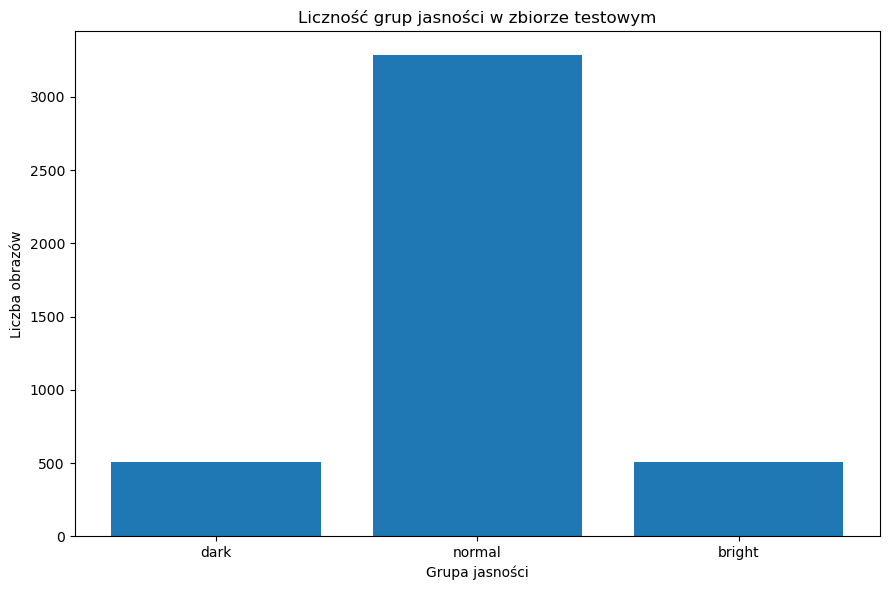

In [29]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.bar(
    plot_df.index,
    plot_df[
        "samples"
    ],
)


ax.set_title(
    "Liczność grup jasności w zbiorze testowym"
)

ax.set_xlabel(
    "Grupa jasności"
)

ax.set_ylabel(
    "Liczba obrazów"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "04_resnet50_lighting_group_test_counts.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 16. Wizualna kontrola grup jasności

Przykładowe obrazy należące do grup `dark`, `normal` i `bright` są prezentowane w celu wizualnej oceny poprawności zastosowanego podziału.

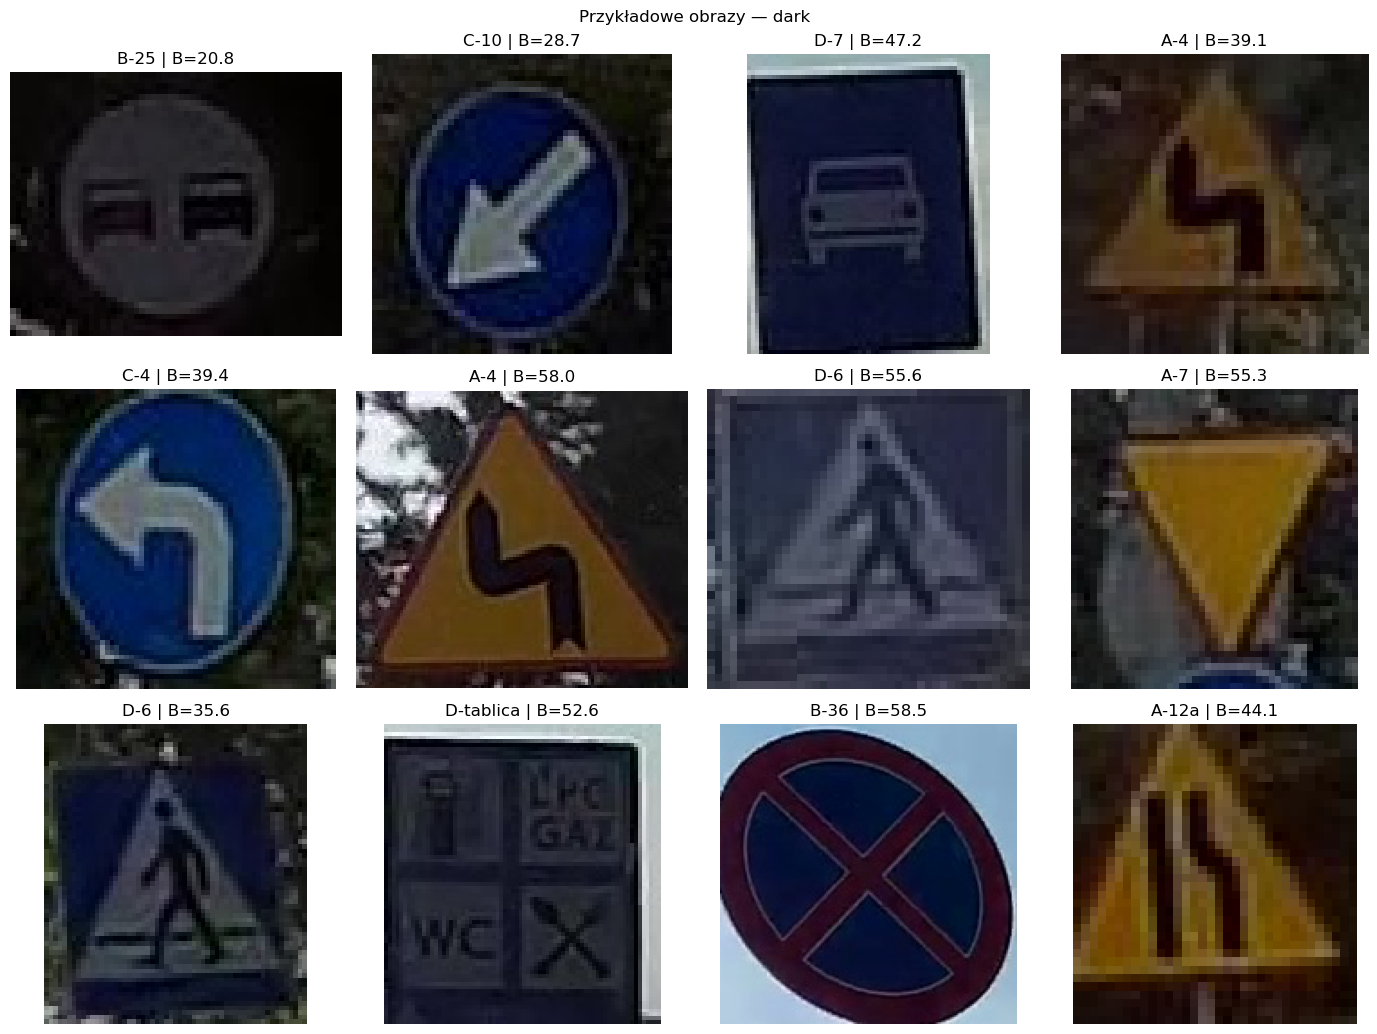

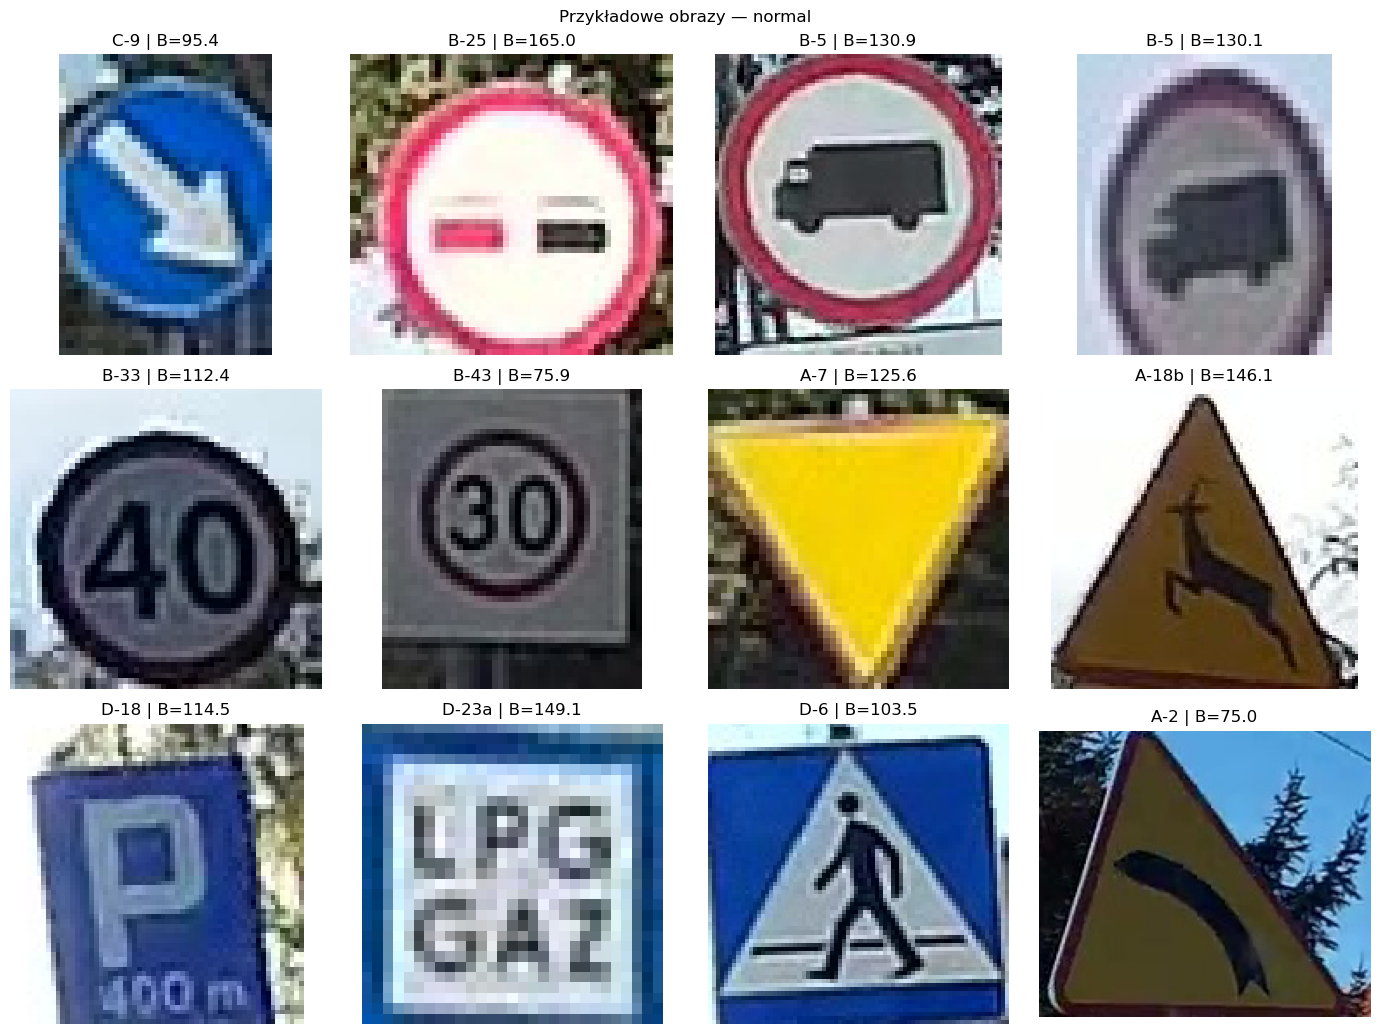

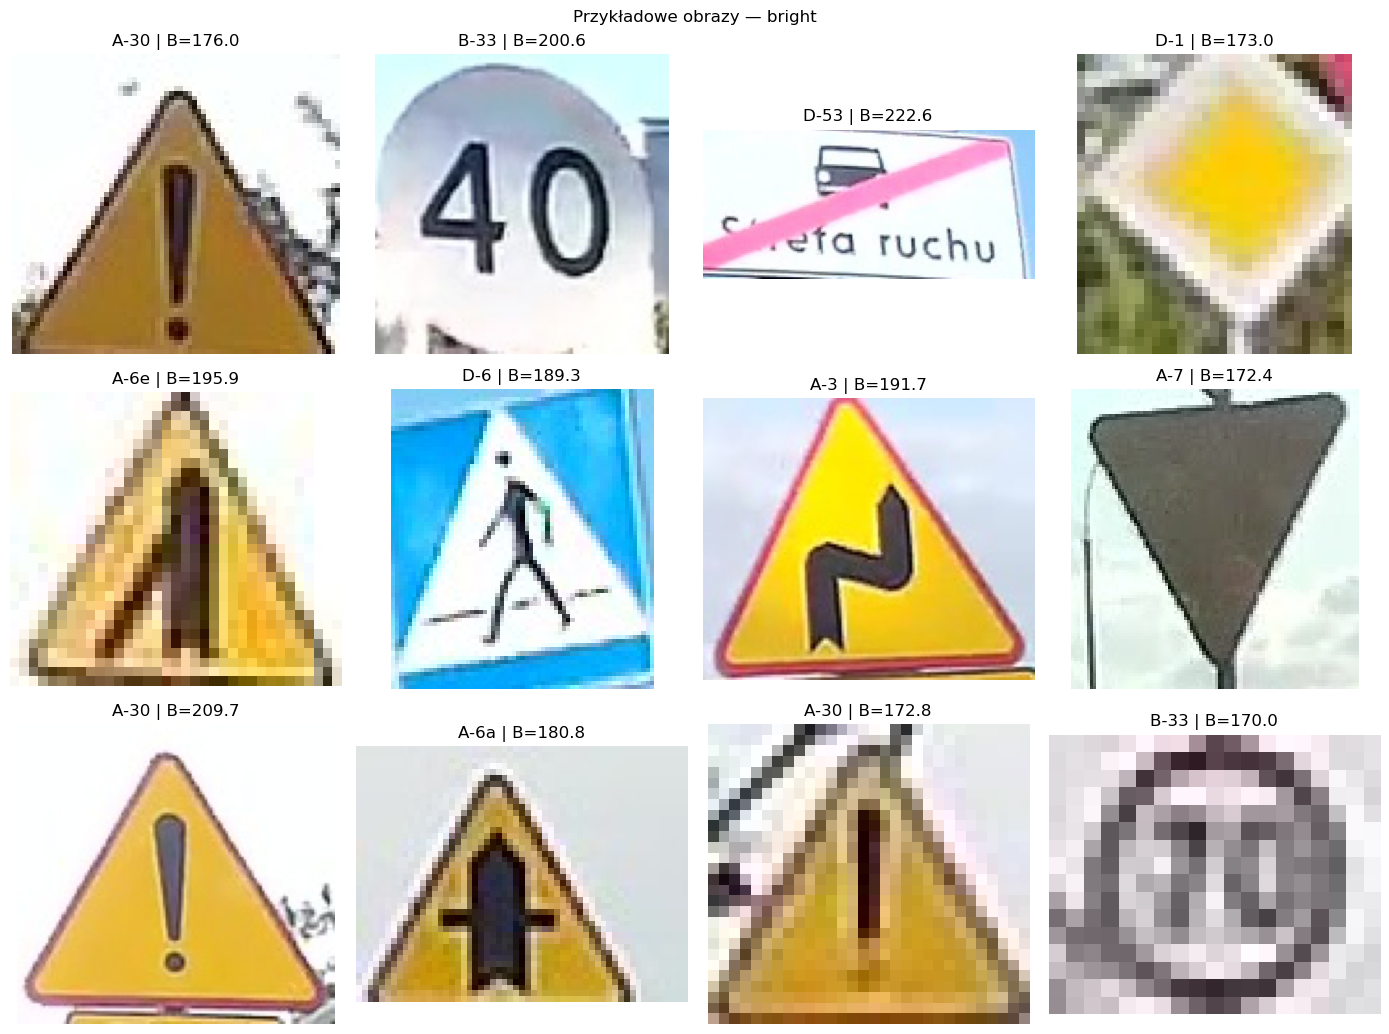

In [30]:
show_lighting_examples(
    test_lighting,
    "dark",
)

show_lighting_examples(
    test_lighting,
    "normal",
)

show_lighting_examples(
    test_lighting,
    "bright",
)

## 17. Analiza błędnych klasyfikacji według poziomu jasności

Dodatkowo analizowane są przypadki błędnie sklasyfikowane przez model w każdej grupie jasności.

In [31]:
errors = test_predictions[
    ~test_predictions[
        "correct"
    ]
].copy()


error_distribution = (
    errors
    .groupby(
        "brightness_group"
    )
    .size()
    .reset_index(
        name="errors"
    )
)


display(
    error_distribution
)

,brightness_group,errors
0,bright,39
1,dark,75
2,normal,315


## 18. Podsumowanie analizy oświetlenia

In [32]:
summary = {
    "brightness_method": "P10_P90",
    "dark_threshold": brightness_p10,
    "bright_threshold": brightness_p90,
    "model": "ResNet50",
    "balancing_strategy": "weighted_sampler",
    "overall_test_accuracy": overall_metrics[
        "accuracy"
    ],
    "overall_test_macro_f1": overall_metrics[
        "macro_f1"
    ],
    "groups": lighting_results_df.to_dict(
        orient="records"
    ),
}


(
    REPORTS_DIR
    / "lighting_analysis_summary.json"
).write_text(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "brightness_method": "P10_P90",
  "dark_threshold": 59.53968009948732,
  "bright_threshold": 168.24337310791014,
  "model": "ResNet50",
  "balancing_strategy": "weighted_sampler",
  "overall_test_accuracy": 0.9001861330851559,
  "overall_test_macro_f1": 0.8829800818611528,
  "groups": [
    {
      "brightness_group": "dark",
      "samples": 505,
      "classes_present": 73,
      "mean_brightness": 44.809502393892494,
      "accuracy": 0.8514851485148515,
      "macro_precision": 0.7940882004134743,
      "macro_recall": 0.7990850011167349,
      "macro_f1": 0.7844129271571556
    },
    {
      "brightness_group": "normal",
      "samples": 3284,
      "classes_present": 89,
      "mean_brightness": 112.51920256922509,
      "accuracy": 0.9040803897685749,
      "macro_precision": 0.8893447713559008,
      "macro_recall": 0.8972462206764102,
      "macro_f1": 0.8852919850646789
    },
    {
      "brightness_group": "bright",
      "samples": 509,
      "classes_present": 53,
  